- # 금융 거래 고객 신용 위험 예측
    금융 거래 데이터를 분석하여 고객 신용 위험을 예측하는 분류 모델 설계

- ### 데이터 출처  
    (원본) https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data  
    (정제) https://www.kaggle.com/datasets/adityapotdar23/german-credit-data?resource=download

- ### 목차
1. 데이터 읽기
2. EDA 및 데이터 정제
3. 데이터 시각화
4. 머신러닝 모델에 학습하기 위한 데이터 전처리
5. 모델 학습 및 평가
6. 예측 수행
7. 불균형 CLASS 데이터 처리

In [632]:
# 기본 데이터 처리 및 시각화
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 관련 라이브러리
from imblearn.over_sampling import SMOTE  # 데이터 불균형 해결용 오버샘플링
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder # MinMaxScaler : 0~1 스케일링, OrdinalEncoder : 범주형 변수 인코더

# 모델 관련 라이브러리
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier      

# 검증지표 관련 라이브러리
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report

SEED = 42

sns.set_theme(style= 'whitegrid') # seaborn 기본 시각화 스타일

# 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 1. 데이터 불러오기

In [633]:
df_origin = pd.read_csv('data/german_credit_data.csv', index_col= 0,encoding="utf-8") # index_col=0  : 0번째인덱스를 인덱스로 지정

df_origin.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [634]:
# 데이터의 크기를 확인
df_origin.shape

(1000, 10)

- `Age`: 나이
- `Sex`: 성별
- `Job`: 직업 (직업 숙련도 정도로 볼 수 있습니다.)
    - 0: 비숙련직 및 비거주자 (unskilled and non-residnet)
    - 1: 비숙련직 및 거주자 (unskilled and resident)
    - 2: 숙련직 (skilled)
    - 3: 전문직 (highly skilled)
- `Housing`: 주거 형태
    - own: 자가
    - rent: 임대
    - free: (정확하지 않음) 정부나 기타 기관에서 지원해주는 주거 형태
- `Saving accounts:` 저축 예금의 잔고 정도
- `Checking account`: 당좌 예금의 잔고 정도
- `Credit amount`: 예금 보유량 (독일 마르크 기준)
- `Duration`: (정확하지 않음) 은행에 예금을 보유한 기간 (월단위)
- `Purpose`: 예금 보유 목적 (특정 물품 구매, 교육용, 휴가용 등등)

In [635]:
df_origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [636]:
df_origin.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


## 2. 데이터 정제
- 결측값, 이상치 데이터 처리

In [637]:
df_origin.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [638]:
df_origin['Saving accounts'].unique()

<StringArray>
[nan, 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

In [639]:
df_origin['Checking account'].unique()

<StringArray>
['little', 'moderate', nan, 'rich']
Length: 4, dtype: str

In [640]:
df_clean = df_origin.copy()  # 원본 데이터로 복사한 데이터프레임

df_clean

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [641]:
# Saving accounts, Checking account 특성의 결측치를 'Others'로 채운다.

df_clean['Saving accounts'] = df_clean['Saving accounts'].fillna('Others')
df_clean['Checking account'] = df_clean['Checking account'].fillna('Others')

df_clean.isna().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [642]:
df_clean['Checking account'].unique()

<StringArray>
['little', 'moderate', 'Others', 'rich']
Length: 4, dtype: str

In [643]:
df_clean['Saving accounts'].unique()

<StringArray>
['Others', 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

## 3. 데이터 시각화
- 변수별 상관관계 시각화해서 확인한다.

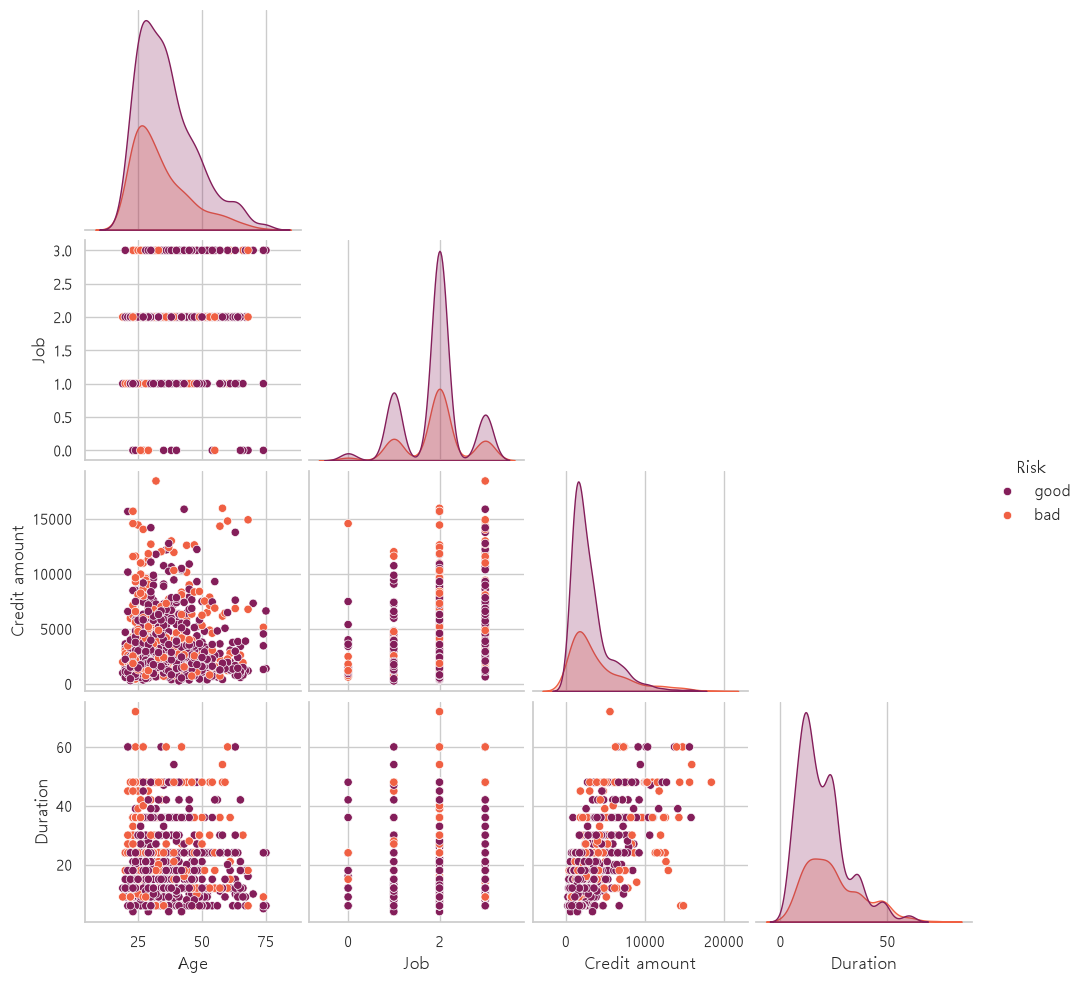

In [644]:
# pairplot : 주요 수치형 변수의 관계/분포를 hue(Risk)의 색상별로 확인

sns.pairplot(
    df_clean,
    vars = ['Age','Job','Credit amount','Duration'], # 비교할 변수
    hue = 'Risk',       # 색상 구분 
    palette= 'rocket',  
    corner= True        # 중복되는 그래프 생략
)
plt.show()

Credit amount 와 Duration 은 약한 양의 상관관계  
job과 Credit amount도 약한 양의 상관관계

<Axes: xlabel='Age', ylabel='Percent'>

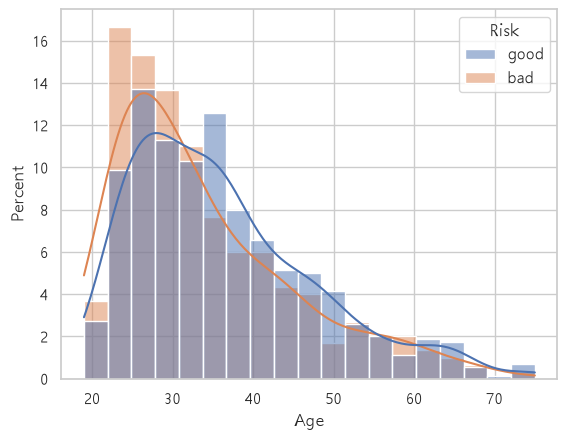

In [645]:
# 분포 확인용 히스토그램(비율로 표시)

sns.histplot(
    df_clean,
    x = 'Age',
    hue = 'Risk',
    kde = True,
    stat = 'percent',   # 비율로 표시
    common_norm= False  # 그룹별 독립 정규화 유무
)

저연령대에서 저신용자가 많고, 30대 중반정도 이후부터 신용도가 좋은 비율이 많음

<Axes: xlabel='Sex', ylabel='Percent'>

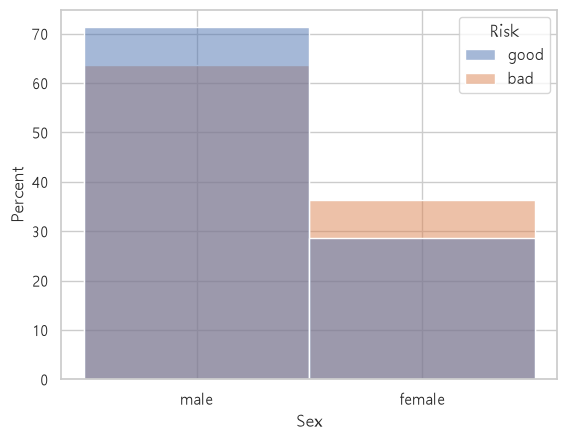

In [646]:
# 분포 확인용 히스토그램(비율로 표시)

sns.histplot(
    df_clean,
    x = 'Sex',
    hue = 'Risk',
    stat = 'percent',   # 비율로 표시
    common_norm= False # 그룹별 독립 정규화 유무
)

남성이 여성보다 상대적으로 신용도 높음

<Axes: xlabel='Job', ylabel='Percent'>

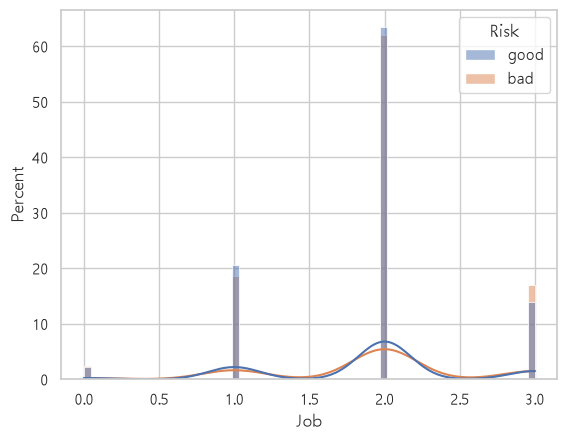

In [647]:
# 분포 확인용 히스토그램(비율로 표시)

sns.histplot(
    df_clean,
    x = 'Job',
    kde= True,
    hue = 'Risk',
    stat = 'percent',   # 비율로 표시
    common_norm= False # 그룹별 독립 정규화 유무
)

숙련직은 신용도가 좋고, 전문직은 다소 떨어지는 경향이 있다.

<Axes: xlabel='Housing', ylabel='Percent'>

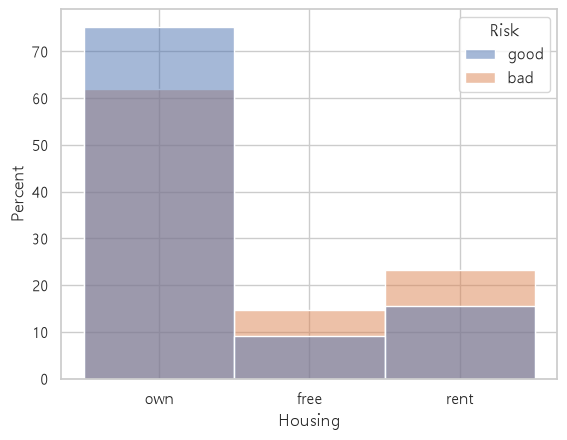

In [648]:
# 분포 확인용 히스토그램(비율로 표시)

sns.histplot(
    df_clean,
    x = 'Housing',
    hue = 'Risk',
    stat = 'percent',   # 비율로 표시
    common_norm= False # 그룹별 독립 정규화 유무
)

자가가 신용도가 높다.

<Axes: xlabel='Checking account', ylabel='Percent'>

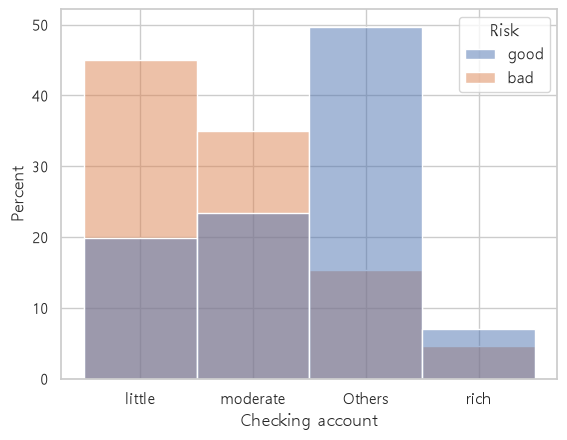

In [649]:
# 분포 확인용 히스토그램(비율로 표시)

sns.histplot(
    df_clean,
    x = 'Checking account',
    hue = 'Risk',
    stat = 'percent',   # 비율로 표시
    common_norm= False # 그룹별 독립 정규화 유무
)

<Axes: xlabel='Saving accounts', ylabel='Percent'>

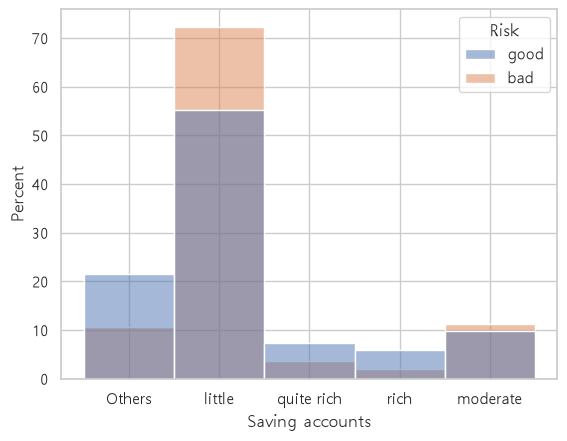

In [650]:
# 분포 확인용 히스토그램(비율로 표시)

sns.histplot(
    df_clean,
    x = 'Saving accounts',
    hue = 'Risk',
    stat = 'percent',   # 비율로 표시
    common_norm= False # 그룹별 독립 정규화 유무
)

잔고가 많으면 신용도가 좋다.

<Axes: xlabel='Credit amount', ylabel='Percent'>

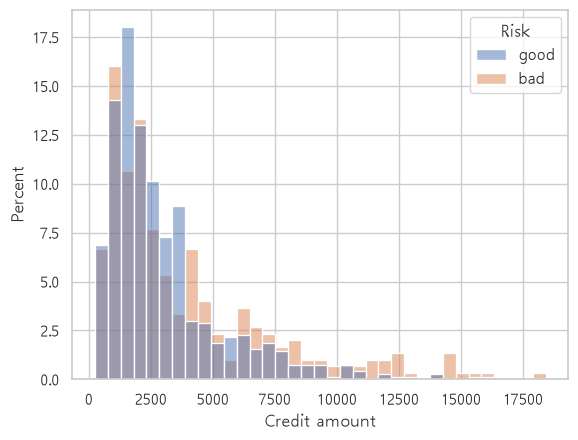

In [651]:
# 분포 확인용 히스토그램(비율로 표시)

sns.histplot(
    df_clean,
    x = 'Credit amount',
    hue = 'Risk',
    stat = 'percent',   # 비율로 표시
    common_norm= False # 그룹별 독립 정규화 유무
)

현금 보유량이 많을수록 위험도가 높은 사람의 비율이 더 많다.

<Axes: xlabel='Duration', ylabel='Percent'>

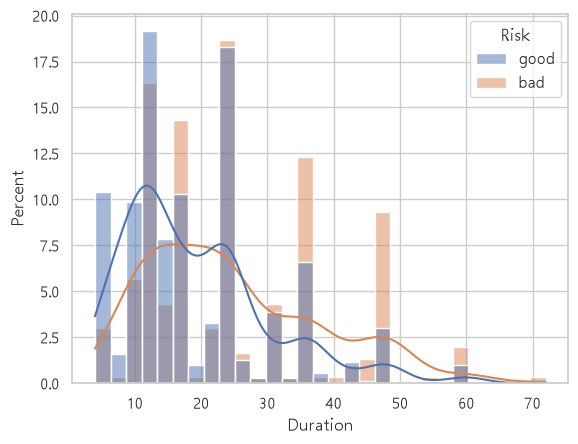

In [652]:
# 분포 확인용 히스토그램(비율로 표시)

sns.histplot(
    df_clean,
    x = 'Duration',
    hue = 'Risk',
    kde= True,
    stat = 'percent',   # 비율로 표시
    common_norm= False # 그룹별 독립 정규화 유무
)

예치 기간이 길수록 신용도가 낮은 사람들의 비율이 높다.

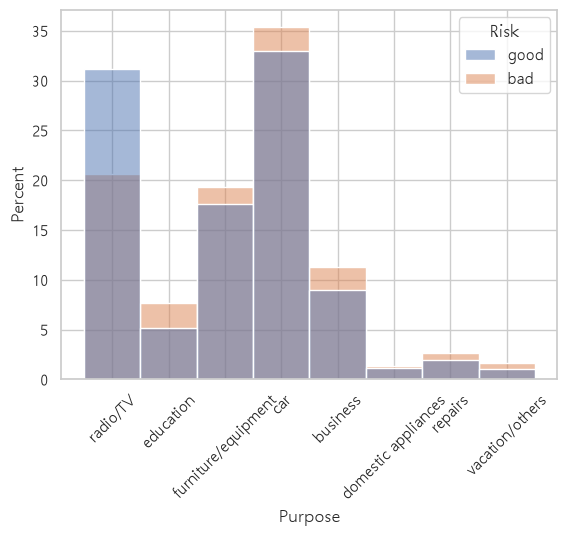

In [653]:
# 분포 확인용 히스토그램(비율로 표시)

sns.histplot(
    df_clean,
    x = 'Purpose',
    hue = 'Risk',
    stat = 'percent',   # 비율로 표시
    common_norm= False # 그룹별 독립 정규화 유무
)
plt.xticks(rotation = 45)
plt.show()

신용 위험도가 낮은 사람들은 생활용품 구매를 위해 예금하는 경향

## 4. 데이터 전처리
- 카테고리형 변수를 수치형 변수로 변환
- 학습 데이터와 테스트 데이터 나누기
- 정규화 : 입력 변수들 값의 크기 범위를 조정

4-1. 수치형 변수 변환

In [654]:
# OrdinalEncoder : 순서가 있는 범주형 인토딩에 주로 사용. 정수형 타입

ord_encoder = OrdinalEncoder(dtype = np.int32)

non_numeriv_features = ['Sex','Housing','Saving accounts','Checking account','Purpose']

# ord_encoder.fit_transform() : 문자 변수들을 순서가 있는 정수로 변환 (기본 사용시 abc순)
df_clean[non_numeriv_features] = ord_encoder.fit_transform(df_clean[non_numeriv_features])


# 순서를 직접 정하는 방식 (인코더를 다른 방식대로 사용했다면 non_numeric_fetures에서 뺴준다.)
# saving_accounts_order = ['Others','little','moderate','qeite rich','rich']
# checking_account_order = ['Others','little','moderate','qeite rich','rich']


# saving_encoder = OrdinalEncoder(categories=[saving_accounts_order], dtype=np.int32)
# df_clean['Saving accounts'] = saving_encoder.fit_transform(df_clean['Saving accounts'])


df_clean

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,good
1,22,0,2,1,1,2,5951,48,5,bad
2,49,1,1,1,1,0,2096,12,3,good
3,45,1,2,0,1,1,7882,42,4,good
4,53,1,2,0,1,1,4870,24,1,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,1,0,1736,12,4,good
996,40,1,3,1,1,1,3857,30,1,good
997,38,1,2,1,1,0,804,12,5,good
998,23,1,2,0,1,1,1845,45,5,bad


In [655]:
ord_encoder.categories_  # 변경 전 원래의 값 확인

[array(['female', 'male'], dtype=object),
 array(['free', 'own', 'rent'], dtype=object),
 array(['Others', 'little', 'moderate', 'quite rich', 'rich'], dtype=object),
 array(['Others', 'little', 'moderate', 'rich'], dtype=object),
 array(['business', 'car', 'domestic appliances', 'education',
        'furniture/equipment', 'radio/TV', 'repairs', 'vacation/others'],
       dtype=object)]

In [656]:
# Risk 변수 good -> 0, bad -> 1로 변환 map(dict)

df_clean['Risk'] = df_clean['Risk'].map({'good': 0, 'bad' : 1})
df_clean

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,0
1,22,0,2,1,1,2,5951,48,5,1
2,49,1,1,1,1,0,2096,12,3,0
3,45,1,2,0,1,1,7882,42,4,0
4,53,1,2,0,1,1,4870,24,1,1
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,1,0,1736,12,4,0
996,40,1,3,1,1,1,3857,30,1,0
997,38,1,2,1,1,0,804,12,5,0
998,23,1,2,0,1,1,1845,45,5,1


4-2 학습, 테스트 데이터 분리

In [657]:
# 전체 데이터에서 입력값을 만들기
X = df_clean.drop('Risk', axis=1)
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,1,2,1,0,1,1169,6,5
1,22,0,2,1,1,2,5951,48,5
2,49,1,1,1,1,0,2096,12,3
3,45,1,2,0,1,1,7882,42,4
4,53,1,2,0,1,1,4870,24,1
...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,1,0,1736,12,4
996,40,1,3,1,1,1,3857,30,1
997,38,1,2,1,1,0,804,12,5
998,23,1,2,0,1,1,1845,45,5


In [658]:
# 전체 데이터에서 정답값 가져오기
y =df_clean['Risk']



<Axes: xlabel='Risk', ylabel='count'>

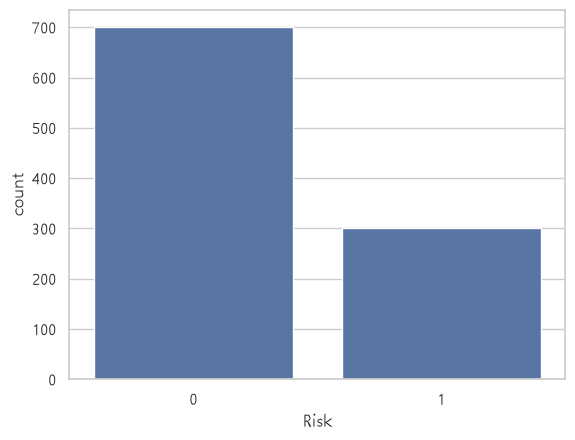

In [659]:
# 타겟 변수의 고유값별 개수

df_clean['Risk'].value_counts()  # 7:3비율 

sns.barplot(df_clean['Risk'].value_counts())


In [660]:
X_train,X_test,y_train,y_test =train_test_split(
    X,y,
    test_size= 0.2,
    random_state = SEED,
    stratify= y     # target의 비율을 테스트/학습 데이터에서 비슷하게 유지
                    # (stratify=y라서 train,test가 7:3으로 분배됨)
)

print(len(X_train),len(y_train),len(X_test),len(y_test))

800 800 200 200


4-3. 정규화

In [661]:
# MinMaxScaler() : 모든 특성값을 0~1 사이로 정규화 해주는 스케일러

scaler = MinMaxScaler()

feature_names = X.columns.tolist()      # 특성 이름 리스트

numeric_features = ['Age','Credit amount','Duration']

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features]) # 수치형 데이터를 기준으로 학습하고, 변환

X_test[numeric_features] = scaler.transform(X_test[numeric_features])       # 테스트 데이터는 학습 데이터 기준으로 (최솟값/최대값) 변환



## 5. 모델 학습 및 평가
- LogisticRegerssion
- Naive Bayes
- Support Vector Machine
- DecisionTree / RandomForest
- XGBoost
- SoftVoting 앙상블

5-1 LogisticRegression

In [662]:
lr_model = LogisticRegression(random_state= SEED)

# 학습
lr_model.fit(X_train, y_train)

print('LogisticRegression 학습 완료')

LogisticRegression 학습 완료


In [663]:
# 예측값 함수

# 각종 평가 지표들을 한 번에 출력해서 확인하고 반환받는 함수
def check_metrix(model,model_name,X_train,X_test,y_train,y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    # zero_division= 0 : 특정 클래스를 하나도 예측하지 못한 경우 경고 대신 0점으로 처리
    # pos_label= 1 : 위험 고객을 얼마나 잘 맞췄는지를 기준으로 계산 !!
    acc_train = accuracy_score(y_train,y_pred_train)
    precision_train = precision_score(y_train,y_pred_train, zero_division= 0)
    recall_train = recall_score(y_train,y_pred_train, zero_division= 0)
    f1_train = f1_score(y_train,y_pred_train, zero_division= 0, pos_label= 1) 
    
    acc_test = accuracy_score(y_test,y_pred_test)
    precision_test = precision_score(y_test,y_pred_test, zero_division= 0)
    recall_test= recall_score(y_test,y_pred_test, zero_division= 0)
    f1_test = f1_score(y_test,y_pred_test, zero_division= 0,pos_label= 1)


    print(f"{model_name}의 학습 정확도 : {acc_train:.4f}")
    print(f"{model_name}의 학습 정밀도 : {precision_train:.4f}")
    print(f"{model_name}의 학습 재헌율 : {recall_train:.4f}")
    print(f"{model_name}의 학습 F1스코어 : {f1_train:.4f}")
    print("-" * 20)
    print(f"{model_name}의 테스트 정확도 : {acc_test:.4f}")
    print(f"{model_name}의 테스트 정밀도 : {precision_test:.4f}")
    print(f"{model_name}의 테스트 재헌율 : {recall_test:.4f}")
    print(f"{model_name}의 테스트 F1스코어 : {f1_test:.4f}")

    return {
        'model' : model_name,
        'accuracy' : acc_test,
        'precision' : precision_test,
        'recall': recall_test,
        'f1_score': f1_test
    }

# 혼동 행렬 계산/시각화 함수

def plot_confusion_matrix(model,model_name,X_train,X_test,y_train,y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test,y_pred)

    sns.heatmap(
        cm,
        annot= True,
        fmt = 'd',
        cmap = 'Blues',
        xticklabels= ['good(0)','bad(1)'],
        yticklabels= ['good(0)','bad(1)']
    )
    plt.xlabel('예측값')
    plt.ylabel('실제값')
    plt.title(f"{model_name}의 혼동 행렬")
    plt.show()

In [664]:
model_results = [] # 모델별 테스트 성능 결과 저장

In [665]:
result = check_metrix(lr_model, "Logistic Regression", X_train,X_test,y_train,y_test)

model_results.append(result)

Logistic Regression의 학습 정확도 : 0.7000
Logistic Regression의 학습 정밀도 : 0.5000
Logistic Regression의 학습 재헌율 : 0.1583
Logistic Regression의 학습 F1스코어 : 0.2405
--------------------
Logistic Regression의 테스트 정확도 : 0.7300
Logistic Regression의 테스트 정밀도 : 0.6500
Logistic Regression의 테스트 재헌율 : 0.2167
Logistic Regression의 테스트 F1스코어 : 0.3250


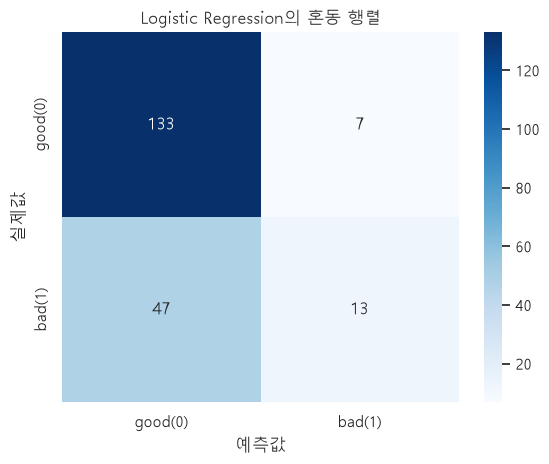

In [666]:
plot_confusion_matrix(lr_model,"Logistic Regression", X_train,X_test,y_train,y_test)

5-2 Naive Bayes

In [667]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

result = check_metrix(nb_model, "Naive Bayes", X_train,X_test,y_train,y_test)

model_results.append(result)

Naive Bayes의 학습 정확도 : 0.7125
Naive Bayes의 학습 정밀도 : 0.5347
Naive Bayes의 학습 재헌율 : 0.3208
Naive Bayes의 학습 F1스코어 : 0.4010
--------------------
Naive Bayes의 테스트 정확도 : 0.7400
Naive Bayes의 테스트 정밀도 : 0.5952
Naive Bayes의 테스트 재헌율 : 0.4167
Naive Bayes의 테스트 F1스코어 : 0.4902


로지스틱 회귀보다 낫긴 하지만, 성능은 과소적합

5-3 Support Vector Machine(SVM)

In [668]:
svm_model = SVC(random_state = SEED, C=10)
svm_model.fit(X_train,y_train)

result = check_metrix(svm_model, "SVM", X_train,X_test,y_train,y_test)

model_results.append(result)

SVM의 학습 정확도 : 0.7837
SVM의 학습 정밀도 : 0.7557
SVM의 학습 재헌율 : 0.4125
SVM의 학습 F1스코어 : 0.5337
--------------------
SVM의 테스트 정확도 : 0.7600
SVM의 테스트 정밀도 : 0.7000
SVM의 테스트 재헌율 : 0.3500
SVM의 테스트 F1스코어 : 0.4667


SVM은 과소적합

5-4 Decision Tree / RandomForest

In [669]:
dt_model = DecisionTreeClassifier(random_state= SEED)

dt_model.fit(X_train,y_train)

result = check_metrix(dt_model, "DecisionTree", X_train,X_test,y_train,y_test)

model_results.append(result)

DecisionTree의 학습 정확도 : 1.0000
DecisionTree의 학습 정밀도 : 1.0000
DecisionTree의 학습 재헌율 : 1.0000
DecisionTree의 학습 F1스코어 : 1.0000
--------------------
DecisionTree의 테스트 정확도 : 0.7000
DecisionTree의 테스트 정밀도 : 0.5000
DecisionTree의 테스트 재헌율 : 0.4500
DecisionTree의 테스트 F1스코어 : 0.4737


DecisionTree는 Max_depth가 없으면 과적합 발생할 가능성이 높다

In [670]:
rf_model = RandomForestClassifier(random_state= SEED)

rf_model.fit(X_train,y_train)

result = check_metrix(rf_model, "RandomForest", X_train,X_test,y_train,y_test)

model_results.append(result)

RandomForest의 학습 정확도 : 1.0000
RandomForest의 학습 정밀도 : 1.0000
RandomForest의 학습 재헌율 : 1.0000
RandomForest의 학습 F1스코어 : 1.0000
--------------------
RandomForest의 테스트 정확도 : 0.7700
RandomForest의 테스트 정밀도 : 0.6667
RandomForest의 테스트 재헌율 : 0.4667
RandomForest의 테스트 F1스코어 : 0.5490


RandomForest도 Max_depth가 없으면 과적합 발생할 가능성이 높다  
과적합 발생하였으나 성능 개선 여지가 보임

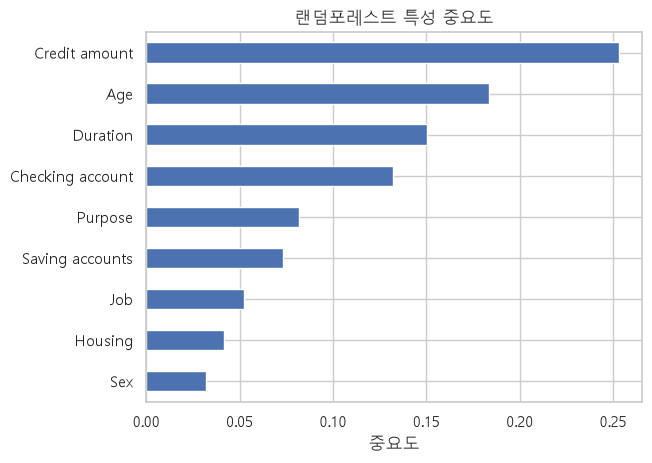

In [671]:
# 트리계열 모델의 특성 중요도 확인
importance = pd.Series(rf_model.feature_importances_,index= feature_names).sort_values()

importance.plot(kind='barh')
plt.title('랜덤포레스트 특성 중요도')
plt.xlabel('중요도')
plt.show()

5-5 XGBoost

In [672]:
xgb_model = XGBClassifier(random_state = SEED)

xgb_model.fit(X_train,y_train)

result = check_metrix(xgb_model, "XGBoost", X_train,X_test,y_train,y_test)

model_results.append(result)

XGBoost의 학습 정확도 : 1.0000
XGBoost의 학습 정밀도 : 1.0000
XGBoost의 학습 재헌율 : 1.0000
XGBoost의 학습 F1스코어 : 1.0000
--------------------
XGBoost의 테스트 정확도 : 0.7450
XGBoost의 테스트 정밀도 : 0.5818
XGBoost의 테스트 재헌율 : 0.5333
XGBoost의 테스트 F1스코어 : 0.5565


XGBoost : 과적합 발생하였으나 성능 개선 여지가 보임

5-6 Voting 앙상블

In [673]:
voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000,random_state=SEED)),
        ('rf', RandomForestClassifier(random_state=SEED)),
        ('xgb', XGBClassifier(random_state=SEED))
    ],
    voting = 'soft'
)


voting_model.fit(X_train,y_train)

result = check_metrix(voting_model, "Soft Voting Ensemble", X_train,X_test,y_train,y_test)

model_results.append(result)

Soft Voting Ensemble의 학습 정확도 : 0.9962
Soft Voting Ensemble의 학습 정밀도 : 1.0000
Soft Voting Ensemble의 학습 재헌율 : 0.9875
Soft Voting Ensemble의 학습 F1스코어 : 0.9937
--------------------
Soft Voting Ensemble의 테스트 정확도 : 0.7600
Soft Voting Ensemble의 테스트 정밀도 : 0.6500
Soft Voting Ensemble의 테스트 재헌율 : 0.4333
Soft Voting Ensemble의 테스트 F1스코어 : 0.5200


Soft Voting Ensemble : 과적합 발생하였으나 성능 개선 여지가 보임

In [674]:
df_model_results = pd.DataFrame(model_results).sort_values('f1_score',ascending= False)

df_model_results

,model,accuracy,precision,recall,f1_score
5,XGBoost,0.745,0.581818,0.533333,0.556522
4,RandomForest,0.770,0.666667,0.466667,0.549020
6,Soft Voting Ensemble,0.760,0.650000,0.433333,0.520000
1,Naive Bayes,0.740,0.595238,0.416667,0.490196
3,DecisionTree,0.700,0.500000,0.450000,0.473684
2,SVM,0.760,0.700000,0.350000,0.466667
0,Logistic Regression,0.730,0.650000,0.216667,0.325000


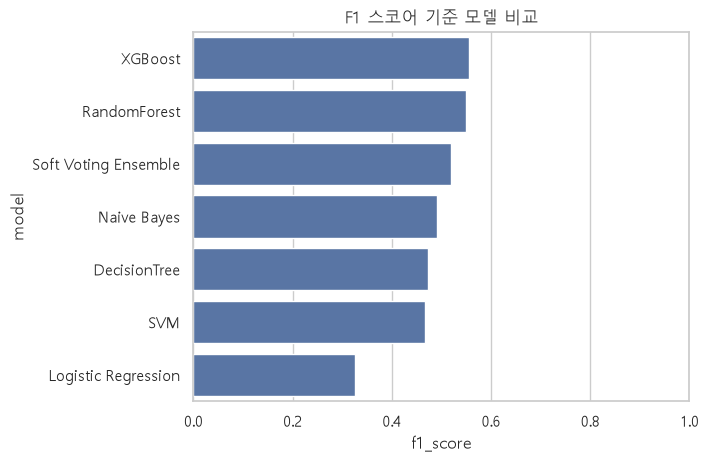

In [675]:
sns.barplot(data=df_model_results, x='f1_score', y='model')
plt.title('F1 스코어 기준 모델 비교')
plt.xlim(0,1)  # x축 범위 설정
plt.show()

## 6. 클래스 불균형 문제
- 데이터 비율이 7:3 이라서 SMOTE를 사용해서 비율을 맞춰주고 진행하면 성능개선 여지가 있다.

In [676]:
# 데이터 증강 기법 SMOTE
smote = SMOTE(random_state= SEED)

# 주의점 : 학습데이터만 증강 적용해야 한다. (테스트 데이터에 적용하면 평가점수가 공정하게 되지 않음)
X_train_over, y_train_over = smote.fit_resample(X_train,y_train)

print(f"증강된 x 데이터 수: {X_train_over.shape[0]}, 증강된 y 데이터 수 : {y_train_over.shape[0]}")

print(pd.Series(y_train_over).value_counts())

증강된 x 데이터 수: 1120, 증강된 y 데이터 수 : 1120
Risk
1    560
0    560
Name: count, dtype: int64


In [677]:
xgb_over_model = XGBClassifier( random_state=SEED)

xgb_over_model.fit(X_train_over,y_train_over)



result = check_metrix(xgb_over_model, "증강된 데이터 XGBClassifier", X_train,X_test,y_train,y_test)

model_results.append(result)

증강된 데이터 XGBClassifier의 학습 정확도 : 1.0000
증강된 데이터 XGBClassifier의 학습 정밀도 : 1.0000
증강된 데이터 XGBClassifier의 학습 재헌율 : 1.0000
증강된 데이터 XGBClassifier의 학습 F1스코어 : 1.0000
--------------------
증강된 데이터 XGBClassifier의 테스트 정확도 : 0.7050
증강된 데이터 XGBClassifier의 테스트 정밀도 : 0.5085
증강된 데이터 XGBClassifier의 테스트 재헌율 : 0.5000
증강된 데이터 XGBClassifier의 테스트 F1스코어 : 0.5042


## 실습 과제 
1. 하이퍼파라미터 튜닝 (Optuna, GridSearchCV, RandomizedSearchCV)
2. 증강한 데이터로 학습해보고 비교해보기
3. piplinde과 ColumnTransformer 사용해서 전처리와 모델 학습을 하나로 묶어서 임의의 데이터로 테스트

## 고도화 실습 과제
- 추론모델을 함수형으로 모듈화시켜 streamlit에서 입력받은 값으로 출력 진행해보기

# 1. Optuna로 하이퍼파라미터 튜닝

In [678]:
rf_model = RandomForestClassifier(random_state= SEED)

rf_model.fit(X_train,y_train)

result = check_metrix(rf_model, "RandomForest", X_train,X_test,y_train,y_test)

model_results.append(result)

RandomForest의 학습 정확도 : 1.0000
RandomForest의 학습 정밀도 : 1.0000
RandomForest의 학습 재헌율 : 1.0000
RandomForest의 학습 F1스코어 : 1.0000
--------------------
RandomForest의 테스트 정확도 : 0.7700
RandomForest의 테스트 정밀도 : 0.6667
RandomForest의 테스트 재헌율 : 0.4667
RandomForest의 테스트 F1스코어 : 0.5490


In [682]:
import optuna
from optuna.samplers import TPESampler  # 이전의 실험 결과를 보고, 성능이 좋을 것같은 조합을 탐색하는 기법
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Optuna 로그가 너무 많이 출력되지 않도록 경고메시지만 출력
optuna.logging.set_verbosity(optuna.logging.WARNING)  

def objective_rf(trial):
    # Optuna가 한 번의 trial에서 사용할 하이퍼파라미터를 제안
    params = {
        "max_depth": trial.suggest_int('max_depth',2,10),
        "min_samples_split": trial.suggest_int('min_samples_split',2,10),
        "min_samples_leaf": trial.suggest_int('min_samples_leaf',1,10),
        "criterion" : trial.suggest_categorical('criterion',['gini','entropy']),# criterion: 노드 분리 기준 (나무계열에서 사용)
    }

    modelrf = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle= True, random_state= SEED)

    # 5-fold 교차검증 정확도 계산
    scores = cross_val_score(modelrf, 
                             X_train, 
                             y_train,                   
                             cv =cv, 
                             scoring = 'f1')
    
    # 교차검증 정확도의 평균이 최대화되는 방향으로 학습
    return scores.mean()

def objective_lr(trial):
    params = {
        "C": trial.suggest_float('C', 0.001, 10, log=True),  # 규제 강도, 로그 스케일 탐색 권장
        'l1_ratio': trial.suggest_categorical('l1_ratio', [0, 1]),
        "solver": "liblinear",  # l1, l2 둘 다 지원하는 solver
        "random_state": SEED
    }

    modellr = LogisticRegression(**params)

    #생존/사망 비율 fold마다 비슷하게 유지되도록 StratifiedKFold 사용
    cv = StratifiedKFold(n_splits=5, shuffle= True, random_state= SEED)

    # 5-fold 교차검증 정확도 계산
    scores = cross_val_score(modellr, 
                             X_train, 
                             y_train,                   
                             cv =cv, 
                             scoring = 'f1')
    
    # 교차검증 정확도의 평균이 최대화되는 방향으로 학습
    return scores.mean()
def objective_XGB(trial):
    params = {
        'learning_rate':0.3, 
        'max_depth':6, 
        'min_child_weight':1, 
        'subsample':1, 
        'reg_alpha':0, 
        'reg_lambda':1,
        'max_delta_step' : 5
    }

    modelxgb = XGBClassifier(**params)

    #생존/사망 비율 fold마다 비슷하게 유지되도록 StratifiedKFold 사용
    cv = StratifiedKFold(n_splits=5, shuffle= True, random_state= SEED)

    # 5-fold 교차검증 정확도 계산
    scores = cross_val_score(modelxgb, 
                             X_train, 
                             y_train,                   
                             cv =cv, 
                             scoring = 'f1')
    
    # 교차검증 정확도의 평균이 최대화되는 방향으로 학습
    return scores.mean()



# 랜덤포레스트 하이퍼파라미터
sampler =TPESampler(seed =SEED)
studyrf = optuna.create_study(direction = 'maximize', sampler = sampler)

studyrf.optimize(objective_rf, n_trials = 50)  # n_trials가 증가되면 시간은 증가되지만, 더 많이 시도해서 탐색

print(f"OptunaXGB 최적의 하이퍼파라미터 : {studyrf.best_params}")
print(f"OptunaXGB 최적의 정확도 : {studyrf.best_value:.4f}")


# 로지스틱 하이퍼파라미터
sampler =TPESampler(seed =SEED)
studylr = optuna.create_study(direction = 'maximize', sampler = sampler)

studylr.optimize(objective_lr, n_trials = 50)  # n_trials가 증가되면 시간은 증가되지만, 더 많이 시도해서 탐색

print(f"OptunaLR 최적의 하이퍼파라미터 : {studylr.best_params}")
print(f"OptunaLR 최적의 정확도 : {studylr.best_value:.4f}")

# XGB 하이퍼파라미터
sampler =TPESampler(seed =SEED)
studyxgb = optuna.create_study(direction = 'maximize', sampler = sampler)

studyxgb.optimize(objective_XGB, n_trials = 50)  # n_trials가 증가되면 시간은 증가되지만, 더 많이 시도해서 탐색

print(f"OptunaXGB 최적의 하이퍼파라미터 : {studyxgb.best_params}")
print(f"OptunaXGB 최적의 정확도 : {studyxgb.best_value:.4f}")


OptunaXGB 최적의 하이퍼파라미터 : {'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 3, 'criterion': 'entropy'}
OptunaXGB 최적의 정확도 : 0.4799
OptunaLR 최적의 하이퍼파라미터 : {'C': 4.484385892149731, 'l1_ratio': 0}
OptunaLR 최적의 정확도 : 0.2237
OptunaXGB 최적의 하이퍼파라미터 : {}
OptunaXGB 최적의 정확도 : 0.5007


In [ ]:
best_params = studyrf.best_params

best_rf_over_model = RandomForestClassifier(**best_params, random_state= SEED)
best_rf_over_model.fit(X_train_over, y_train_over)
print('학습완료')
result = check_metrix(best_rf_over_model, "Optuna_best_RandomForest", X_train,X_test,y_train,y_test)

model_results.append(result)

학습완료
Optuna_best_RandomForest의 학습 정확도 : 0.8750
Optuna_best_RandomForest의 학습 정밀도 : 0.7518
Optuna_best_RandomForest의 학습 재헌율 : 0.8708
Optuna_best_RandomForest의 학습 F1스코어 : 0.8069
--------------------
Optuna_best_RandomForest의 테스트 정확도 : 0.6800
Optuna_best_RandomForest의 테스트 정밀도 : 0.4737
Optuna_best_RandomForest의 테스트 재헌율 : 0.6000
Optuna_best_RandomForest의 테스트 F1스코어 : 0.5294


In [ ]:
best_params = studylr.best_params

best_lr_over_model = LogisticRegression(**best_params, random_state= SEED)
best_lr_over_model.fit(X_train_over, y_train_over)
print('학습완료')
result = check_metrix(best_lr_over_model, "Optuna_best_Logistic", X_train,X_test,y_train,y_test)

model_results.append(result)

학습완료
Optuna_best_Logistic의 학습 정확도 : 0.6500
Optuna_best_Logistic의 학습 정밀도 : 0.4401
Optuna_best_Logistic의 학습 재헌율 : 0.6125
Optuna_best_Logistic의 학습 F1스코어 : 0.5122
--------------------
Optuna_best_Logistic의 테스트 정확도 : 0.6650
Optuna_best_Logistic의 테스트 정밀도 : 0.4598
Optuna_best_Logistic의 테스트 재헌율 : 0.6667
Optuna_best_Logistic의 테스트 F1스코어 : 0.5442
